In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df=pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


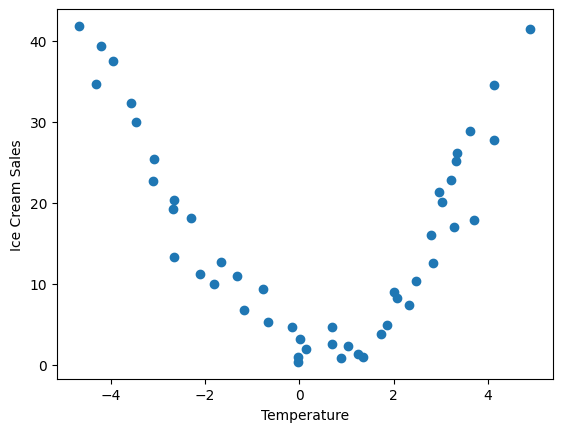

In [4]:
# Extra
plt.scatter(df["Temperature (°C)"],df["Ice Cream Sales (units)"])
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.show()

In [5]:
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [7]:
y=df["Ice Cream Sales (units)"]
x=df[["Temperature (°C)"]]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)


In [9]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((39, 1), (10, 1), (39,), (10,))

In [12]:
poly=PolynomialFeatures(degree=3)

In [14]:
x_train_poly=poly.fit_transform(x_train)
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00,
        -1.86578436e+01],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00,
      

In [16]:
lr=LinearRegression()
lr.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
m=lr.coef_
m

array([ 0.        , -1.39956426,  1.87501919,  0.05451597])

In [18]:
c=lr.intercept_
c

np.float64(2.840530985282797)

In [19]:
x1=poly.transform([[25]])
x1

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.0000e+00, 2.5000e+01, 6.2500e+02, 1.5625e+04]])

In [21]:
p1=lr.predict(x1)
p1

array([1991.55040278])

In [24]:
print(f"MSE = {mean_squared_error(y_test,lr.predict(poly.transform(x_test)))}")


MSE = 15.120009451229496


In [26]:
print(f"MAE = {mean_absolute_error(y_test,lr.predict(poly.transform(x_test)))}")


MAE = 3.22812112977689


In [28]:
print(f"r2 score = {r2_score(y_test,lr.predict(poly.transform(x_test)))}")

r2 score = 0.8405107685716914
